Костин Арсений, 8Е21, вариант 3.

Лабораторная работа №2. Визуальная одометрия (навигация)
Цель: Разработать систему визуальной одометрии (навигации) по группе фотографий.
Ход работы: сделайте не менее 8 фото с переносом камеры или ноутбука по квадрату (то есть двиньте сначала вправо, потом вперед, потом влево, потом назад и обратно в начальную точку). Используя данные фотографии реализуйте следующее:
<p> 1.	Определите на каждой фотографии ключевые точки </p>
<p>2.	Отфильтруйте самые наилучшие применяю адаптивный радиус и локальные максимумы, не забудьте так же выровнять по яркости изображения.</p>
<p>3.	Постройте по каждой точке дескриптор (можете использовать любой, рекомендуется SIFT)</p>
<p>4.	Сопоставьте два соседних изображения на предмет соответствия ключевых точек. То есть определите пары одинаковых точек.</p>
<p>5.	Постройте модель преобразования изображений, учитывайте только поворот и сдвиг.</p>
<p>6.	С учетом полученных моделей постройте траекторию движения камеры.</p>
<p>Проверка работоспособности: будет осуществляться на специальной группе фото, предоставленных преподавателем. Траектория движения, для которых недоступна.</p>
<p>В процессе выполнения вы можете использовать готовые функции по погрузке данных, перевода в цветовые пространства, фильтрации, для построения прямых и траекторий. Функции 1-6 описанные выше должны быть реализованы самостоятельно.</p>


In [5]:
import numpy as np
import cv2
import matplotlib
import matplotlib.pyplot as plt
import random
#from PIL import Image
from IPython.display import Image
%matplotlib inline
import math

import os
print(os.getcwd())
print(os.listdir())

/home/ars/cv-labs-sem8/lab1
['sequence5.jpeg', 'sample_image2.png', 'sequence4.jpeg', 'doodles.ipynb', 'lab1.ipynb', 'sequence6.jpeg', 'sample_image3.png', 'sequence8.jpeg', 'sample_image.jpg', 'histfunc.png', 'sequence3.jpeg', 'sample_image4.jpg', 'output.gif', 'sequence7.jpeg', 'sample_image5.jpg', 'gaussfunc.png', 'sequence1.jpeg', 'sequence2.jpeg', 'lab2.ipynb']


Приступим, импортируем сделанные изображения:

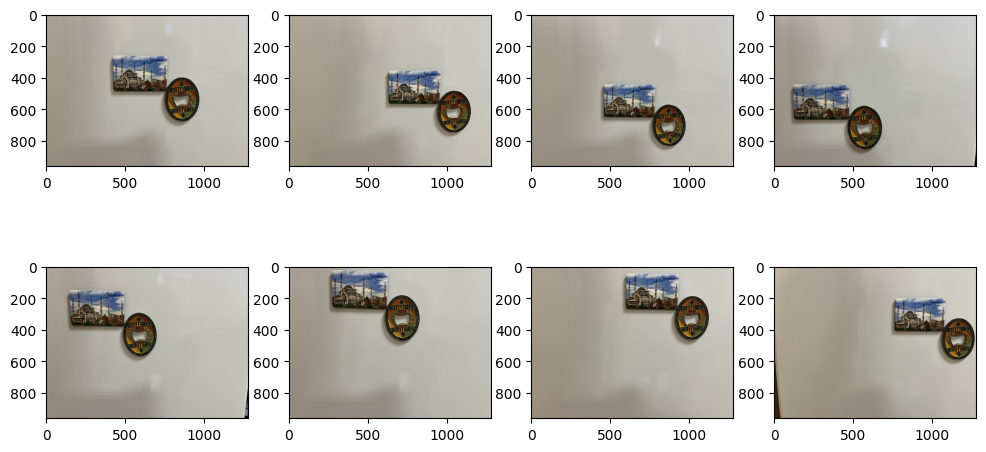

In [16]:
image1=cv2.cvtColor(cv2.imread('sequence1.jpeg'), cv2.COLOR_BGR2RGB)
image2=cv2.cvtColor(cv2.imread('sequence2.jpeg'), cv2.COLOR_BGR2RGB)
image3=cv2.cvtColor(cv2.imread('sequence3.jpeg'), cv2.COLOR_BGR2RGB)
image4=cv2.cvtColor(cv2.imread('sequence4.jpeg'), cv2.COLOR_BGR2RGB)
image5=cv2.cvtColor(cv2.imread('sequence5.jpeg'), cv2.COLOR_BGR2RGB)
image6=cv2.cvtColor(cv2.imread('sequence6.jpeg'), cv2.COLOR_BGR2RGB)
image7=cv2.cvtColor(cv2.imread('sequence7.jpeg'), cv2.COLOR_BGR2RGB)
image8=cv2.cvtColor(cv2.imread('sequence8.jpeg'), cv2.COLOR_BGR2RGB)

images_sequence = [image1, image2, image3, image4, image5, image6, image7, image8]

f, axarr = plt.subplots(2,4, figsize = (12,6))

axarr[0,0].imshow(image1)
axarr[0,1].imshow(image2)
axarr[0,2].imshow(image3)
axarr[0,3].imshow(image4)

axarr[1,0].imshow(image5)
axarr[1,1].imshow(image6)
axarr[1,2].imshow(image7)
axarr[1,3].imshow(image8)

Лирическое отступление - чтобы не размазывать отчет, работа будет вестись над grayscale изображениями. То что мы будем использовать - не зависит от цветов, как видно из первой лабы. Все что возможно - можно сделать для RGB повторяя те же операций и преобразования, просто трижды - по разу для каждого цветового канала. Это не цель лабораторной работы. Приступим, переведем изображения в черно-белый формат, используя функцию из прошлой лабы.